In [ ]:
#prepared.csv has been received by manipulations with transactions_data.xlsx in LibreOffice Calc(Excel for Linux)

In [ ]:
# Task 1
import pandas as pd
import numpy as np

# --- Step 1: Load with fixed columns ---
columns = ['transaction_id', 'client_id', 'transaction_date', 'service',
           'amount', 'payment_method', 'city', 'consultant']

data = pd.read_csv('prepared.csv', header=None)
data.columns = columns

# --- Step 2: Replace empty strings/whitespace with NaN ---
data.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# --- Step 3: Fill transaction_id and client_id with "Unknown" ---
data['transaction_id'] = data['transaction_id'].fillna('Unknown')
data['client_id'] = data['client_id'].fillna('Unknown')

# --- Step 4: Standardize dates *without forcing datetime dtype* ---
# Convert valid dates to standard format, leave invalid as-is
def standardize_date(date_str):
    if pd.isna(date_str) or date_str == 'INVALID_DATE':
        return 'INVALID_DATE'
    try:
        dt = pd.to_datetime(date_str, errors='coerce')
        return dt.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(dt) else 'INVALID_DATE'
    except Exception:
        return 'INVALID_DATE'

data['transaction_date'] = data['transaction_date'].astype(str).apply(standardize_date)

# --- Step 5: Handle amount: compute mean only on values ≤ 120,000 ---
data['amount'] = pd.to_numeric(data['amount'], errors='coerce')  # non-numeric → NaN

# Filter to valid values only (not NaN) and ≤ 120,000
valid_amounts = data.loc[data['amount'].notna() & (data['amount'] <= 120_000), 'amount']

# Compute mean on this filtered subset
mean_amount = valid_amounts.mean()

# Fill missing amount with this mean (only if mean is defined)
if pd.isna(mean_amount):
    print("⚠️ No valid amounts ≤ 120,000 found — keeping NaN for amount")
else:
    print(f"✅ Using mean = {mean_amount:,.2f} (computed from {len(valid_amounts)} values ≤ 120,000)")
    data['amount'] = data['amount'].fillna(mean_amount)

# --- Step 6: Skip payment_method, city, consultant (no changes) ---

# --- Step 7: Save ---
data.to_csv('prepared_cleaned.csv', index=False)

# --- Summary ---
invalid_dates = (data['transaction_date'] == 'INVALID_DATE').sum()
print("\n✅ Final cleaning summary:")
print(f"  - transaction_id & client_id → filled with 'Unknown'")
print(f"  - amount: mean filled = {mean_amount:,.2f} (used {len(valid_amounts)} values ≤ 120,000)")
print(f"  - transaction_date: invalid dates preserved after standardization: {invalid_dates}")

✅ Using mean = 43,849.71 (computed from 9037 values ≤ 120,000)

✅ Final cleaning summary:
  - transaction_id & client_id → filled with 'Unknown'
  - amount: mean filled = 43,849.71 (used 9037 values ≤ 120,000)
  - transaction_date: invalid dates preserved after standardization: 1006


In [ ]:
#Debugging cell, checked how pandas sees data.
import pandas as pd

# Read with NO header inference
data_raw = pd.read_csv('prepared.csv', header=None)

print("First 5 rows, **column-wise raw values**:")
for i in range(25):
    row = data_raw.iloc[i]
    print(f"Row {i}: {row.tolist()}")

# Count commas per line
with open('prepared.csv') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:26]):
    print(f"Line {i} has {line.strip().count(',')} commas → expects {line.strip().count(',') + 1} fields.")

First 5 rows, **column-wise raw values**:
Row 0: ['transaction_id', 'client_id', 'transaction_date', 'service', 'amount', 'payment_method', 'city', 'consultant']
Row 1: ['ff36597c-df41-44a0-9f46-6aa1fe615270', '1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7', '2025-01-04 00:02:20', 'Структурирование капитала', '55838.0597887567', 'Банковский перевод', 'North Patrickport', 'Cheryl Waller']
Row 2: ['0d5263ec-413d-44d9-a9d3-a996e3a56b05', 'c940f45c-d29b-439a-8fa3-f75018cef528', '2025-03-10 17:16:50', 'Структурирование капитала', '37514.8092094764', 'Неизвестно', 'New Zacharyport', 'Frank Pollard']
Row 3: ['5e9a8978-df1c-483f-a53b-16149c93f11e', 'cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c', '2025-02-13 19:43:49', 'Структурирование капитала', '21022.1468718863', 'Неизвестно', 'Port Michellemouth', 'Alexandra Meyer']
Row 4: ['524031ea-56e2-410a-aee2-e8fc6ae3fbc5', nan, '2025-03-02 03:14:10', 'Финансовое планирование', '2313.9802185852', 'Неизвестно', 'Erichaven', 'Patricia Haas']
Row 5: ['421aaf04-c97d-42ac

In [ ]:
# Task 2
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- Load cleaned data ---
data = pd.read_csv('prepared_cleaned.csv')

# 🔧 Clean column names (remove extra spaces/trailing underscores)
data.columns = data.columns.str.strip().str.replace(r'_$', '', regex=True)

# --- Helper: Parse dates and get last month bounds ---
def get_date_bounds(df, date_col='transaction_date'):
    dates = pd.to_datetime(df[date_col], errors='coerce')
    valid_dates = dates.dropna()
    if valid_dates.empty:
        raise ValueError("No valid dates in transaction_date")
    max_date = valid_dates.max().normalize()
    return max_date, max_date - timedelta(days=30)

max_date, last_month_start = get_date_bounds(data)

# --- Prepare report ---
report_lines = []
report_lines.append("📊 DATA ANALYSIS REPORT")
report_lines.append("=" * 60)
report_lines.append(f"Latest date in dataset: {max_date.strftime('%Y-%m-%d')}")
report_lines.append(f"Analyzing last month: {last_month_start.strftime('%Y-%m-%d')} – {max_date.strftime('%Y-%m-%d')}")
report_lines.append("")

# --- 1️⃣ Top 5 most popular services (by order count) ---
service_counts = data['service'].value_counts()
top_5_services = service_counts.head(5)

report_lines.append("🏆 TOP 5 MOST POPULAR SERVICES (BY ORDER COUNT)")
report_lines.append("-" * 60)
for i, (service, count) in enumerate(top_5_services.items(), 1):
    report_lines.append(f"{i}. {service}: {count:,} orders")
report_lines.append("")

# --- 2️⃣ Average transaction amount per city ---
data['amount'] = pd.to_numeric(data['amount'], errors='coerce')

# Avoid column-name corruption (e.g., 'city' as value)
data_clean = data[data['city'] != 'city']

city_avg = data_clean.groupby('city')['amount'].mean().sort_values(ascending=False)

report_lines.append("📈 AVERAGE TRANSACTION AMOUNT PER CITY")
report_lines.append("-" * 60)
for city, avg_amount in city_avg.items():
    report_lines.append(f"  {city}: {avg_amount:,.2f}")
report_lines.append("")

# --- 3️⃣ Service with highest total revenue ---
service_revenue = data.groupby('service')['amount'].sum().sort_values(ascending=False)
top_service = service_revenue.index[0]
top_revenue = service_revenue.iloc[0]

report_lines.append("💰 SERVICE WITH HIGHEST REVENUE")
report_lines.append("-" * 60)
report_lines.append(f"'{top_service}': {top_revenue:,.2f}")
report_lines.append("")

# --- 4️⃣ Payment method breakdown ---
# Filter out corruption like 'payment_method' as a value
data_clean = data_clean[data_clean['payment_method'] != 'payment_method']

payment_counts = data_clean['payment_method'].value_counts()
total_payments = payment_counts.sum()
payment_pct = (payment_counts / total_payments * 100).round(2)

report_lines.append("📊 TRANSACTION SHARE BY PAYMENT METHOD")
report_lines.append("-" * 60)
for method, pct in payment_pct.items():
    report_lines.append(f"  {method}: {pct:.2f}% ({payment_counts[method]:,} transactions)")
report_lines.append("")

# --- 5️⃣ Revenue for the last month ---
data_clean['date_parsed'] = pd.to_datetime(data_clean['transaction_date'], errors='coerce')
last_month_mask = (data_clean['date_parsed'] >= last_month_start) & (data_clean['date_parsed'] <= max_date)
last_month_amounts = data_clean.loc[last_month_mask, 'amount'].dropna()

last_month_revenue = last_month_amounts.sum()
last_month_count = len(last_month_amounts)

report_lines.append("📅 REVENUE FOR LAST MONTH")
report_lines.append("-" * 60)
report_lines.append(f"Period: {last_month_start.strftime('%Y-%m-%d')} – {max_date.strftime('%Y-%m-%d')}")
report_lines.append(f"Total revenue: {last_month_revenue:,.2f}")
report_lines.append(f"Number of transactions: {last_month_count:,}")
report_lines.append("")

# --- Save report ---
report_text = "\n".join(report_lines)
with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)
print("\n✅ Report saved to 'analysis_report.txt'")

📊 DATA ANALYSIS REPORT
Latest date in dataset: 2025-03-20
Analyzing last month: 2025-02-18 – 2025-03-20

🏆 TOP 5 MOST POPULAR SERVICES (BY ORDER COUNT)
------------------------------------------------------------
1. Инвестиционное консультирование: 2,429 orders
2. Управление активами: 2,014 orders
3. Финансовое планирование: 1,532 orders
4. Налоговое планирование: 1,528 orders
5. Структурирование капитала: 1,507 orders

📈 AVERAGE TRANSACTION AMOUNT PER CITY
------------------------------------------------------------
  Port Michellemouth: 55,734.99
  Michellehaven: 55,033.58
  East Rachelmouth: 53,816.91
  New Tommyborough: 53,409.12
  Trevinoberg: 52,617.16
  North Melissaland: 52,423.48
  North Lauriebury: 52,335.04
  New Zacharyport: 52,203.02
  Kaneburgh: 51,969.12
  Johnsonfort: 51,805.77
  Harrisberg: 51,623.62
  Bondstad: 51,107.49
  Lake Tina: 51,060.50
  West Meredithhaven: 51,032.97
  North Emily: 50,901.60
  Lake Arielmouth: 50,581.39
  Krystalland: 50,474.50
  South Andrew:

/tmp/ipykernel_181339/1147319943.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')


In [1]:
# Task 3
import pandas as pd
import json

# --- File paths ---
clients_file = 'Test_Task/clients_data.json'
transactions_file = 'prepared_cleaned.csv'
output_csv = 'Final.csv'

# --- Step 1: Load & clean clients JSON ---
with open(clients_file, 'r', encoding='utf-8') as f:
    clients_list = json.load(f)
clients = pd.DataFrame(clients_list)
clients.columns = clients.columns.str.strip()
clients.rename(columns={'id': 'client_id'}, inplace=True)
clients = clients.dropna(subset=['client_id'])
clients['client_id'] = clients['client_id'].astype(str).str.strip()
print(f"✅ Loaded {len(clients):,} clients")

# --- Step 2: Load & clean transactions ---
transactions = pd.read_csv(transactions_file)
transactions.columns = transactions.columns.str.strip()

# Remove header-as-data rows
for col in transactions.columns:
    mask = transactions[col].astype(str).str.strip() == col
    transactions = transactions[~mask]

transactions['client_id'] = transactions['client_id'].astype(str).str.strip()
print(f"✅ Loaded {len(transactions):,} transactions")

# --- Step 3: Merge (left join) ---
merged = transactions.merge(
    clients[['client_id', 'net_worth', 'age', 'gender']],
    on='client_id',
    how='left'
)

# --- Step 4: Replace NaNs with "null" for client fields ---
merged['net_worth'] = merged['net_worth'].apply(lambda x: 'null' if pd.isna(x) else x)
merged['age'] = merged['age'].apply(lambda x: 'null' if pd.isna(x) else x)
merged['gender'] = merged['gender'].fillna('Unknown')

# --- Step 5: Define asset_level using net_worth ---
def asset_category(row):
    nw = row['net_worth']
    if nw == 'null':
        return 'Unknown (no client data)'
    elif float(nw) < 100_000:
        return 'Low net worth (<100k)'
    elif float(nw) <= 1_000_000:
        return 'Medium net worth (100k–1M)'
    else:
        return 'High net worth (>1M)'

merged['asset_level'] = merged.apply(asset_category, axis=1)

# Optional: also fill other columns with "Unknown"
for col in ['transaction_id', 'service', 'payment_method', 'city', 'consultant']:
    merged[col] = merged[col].fillna('Unknown')

# --- Step 6: Export ---
merged.to_csv(output_csv, index=False)

print(f"\n✅ Enriched CSV saved: '{output_csv}'")
print("\n📊 Summary of asset_level:")
print(merged['asset_level'].value_counts())

✅ Loaded 9,798 clients
✅ Loaded 10,000 transactions

✅ Enriched CSV saved: 'Final.csv'

📊 Summary of asset_level:
asset_level
High net worth (>1M)          7510
Medium net worth (100k–1M)    1639
Unknown (no client data)       677
Low net worth (<100k)          174
Name: count, dtype: int64


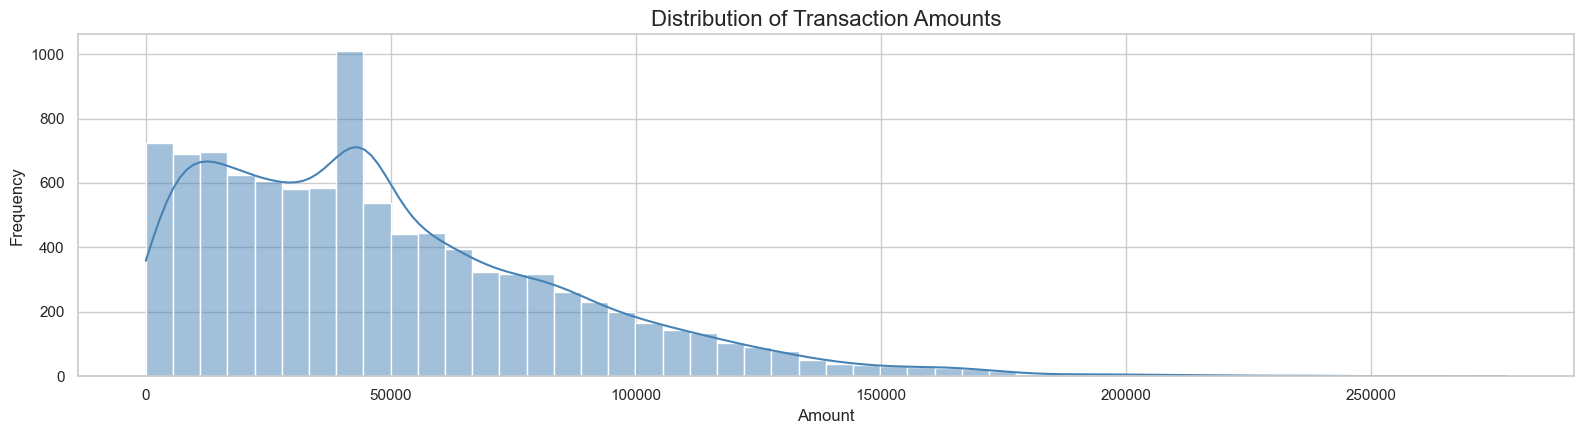

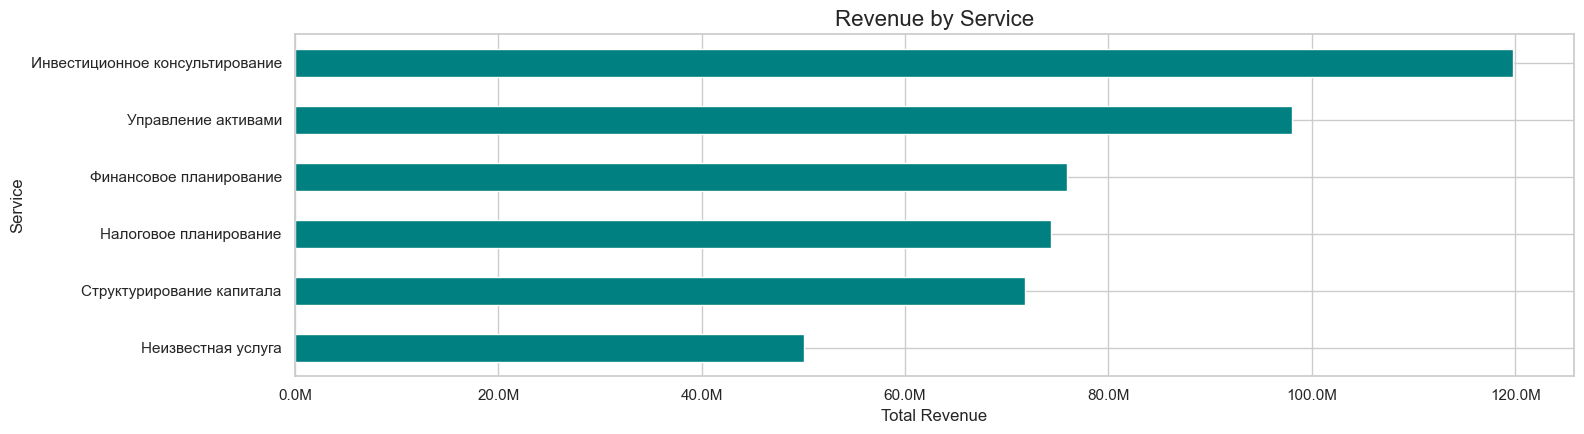

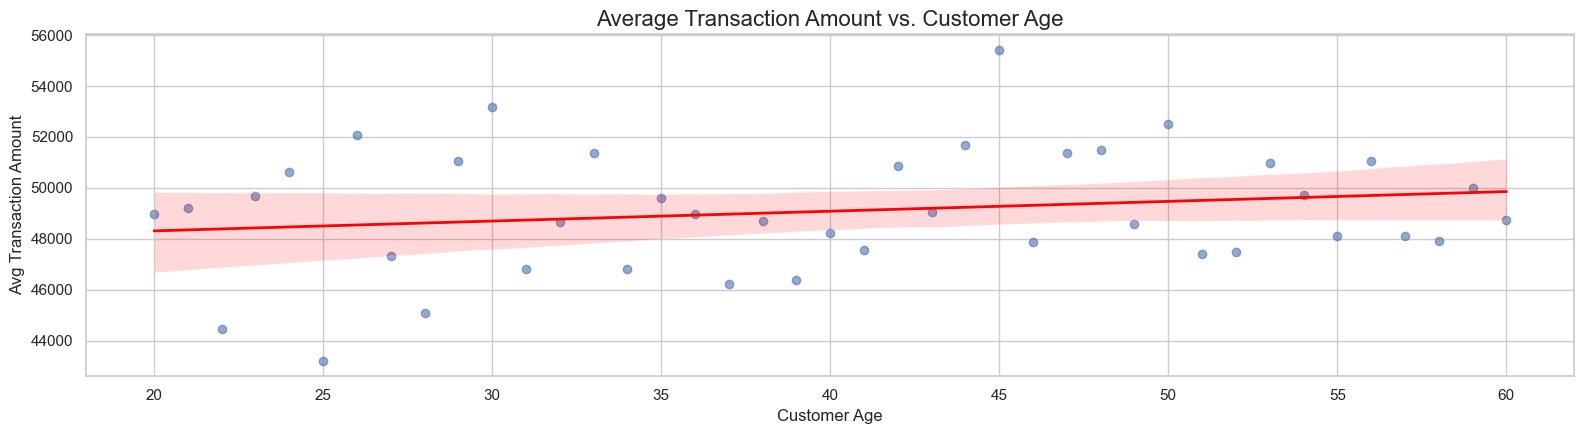

In [ ]:
# Task 4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv('Final.csv')
df.columns = df.columns.str.strip()

# Convert numeric columns
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['net_worth'] = pd.to_numeric(df['net_worth'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Filter rows with valid age for age-based plots
df_with_age = df[df['age'].notna() & (df['age'] > 0)].copy()

# --- Plot setup ---
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 4.5)

# --- 1️⃣ Transaction amount distribution ---
plt.figure()
sns.histplot(df['amount'].dropna(), bins=50, kde=True, color='steelblue')
plt.title('Distribution of Transaction Amounts', fontsize=16)
plt.xlabel('Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2️⃣ Revenue by service ---
revenue_by_service = df.groupby('service')['amount'].sum().sort_values(ascending=True)
plt.figure()
bars = revenue_by_service.plot(kind='barh', color='teal')
plt.title('Revenue by Service', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Service', fontsize=12)
# Format x-axis as millions (e.g., 1.2M)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# --- 3️⃣ Avg transaction amount vs. customer age ---
# Group by age and get average amount
age_avg = df_with_age.groupby('age')['amount'].mean().reset_index()

plt.figure()
sns.regplot(data=age_avg, x='age', y='amount', 
            scatter_kws={'alpha': 0.6}, 
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Average Transaction Amount vs. Customer Age', fontsize=16)
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Avg Transaction Amount', fontsize=12)
plt.tight_layout()
plt.show()

📊 Available months:
  year_month  transaction_count
0    2025-01               3554
1    2025-02               3223
2    2025-03               2218
Total unique months: 3

📈 Forecasting using last 3 months (min=3, max=5):
  year_month  transaction_count  relative_index
0    2025-01               3554               0
1    2025-02               3223               1
2    2025-03               2218               2

📈 Forecast:
  Last month: 2025-03 — 2218 transactions
  Predicted next month (2025-04): 1662 transactions
  Slope: -668.00 transactions/month


/mnt/MySSD/Python_Projects/aasdasdasd/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/mnt/MySSD/Python_Projects/aasdasdasd/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


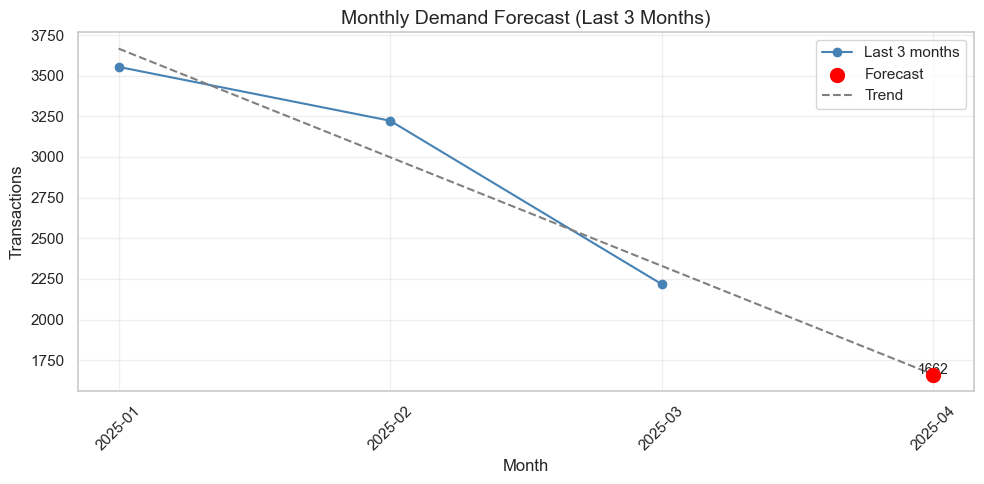

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# --- Load data ---
df = pd.read_csv('Final.csv')
df.columns = df.columns.str.strip()

# Parse dates
df['date_parsed'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df = df.dropna(subset=['date_parsed'])
df['year_month'] = df['date_parsed'].dt.strftime('%Y-%m')

# Aggregate by month
monthly_counts = df.groupby('year_month').size().reset_index(name='transaction_count')
monthly_counts = monthly_counts.sort_values('year_month').reset_index(drop=True)

print("📊 Available months:")
print(monthly_counts)
print(f"Total unique months: {len(monthly_counts)}")

# Use min 3, max 5
n = min(5, len(monthly_counts))
if n < 3:
    print(f"⚠️ Only {n} months available — need at least 3 for meaningful forecast")
n = max(3, n)  # enforce minimum 3 (pad if needed)

# Use last n months
last_n = monthly_counts.tail(n).copy()
last_n['relative_index'] = np.arange(n)

print(f"\n📈 Forecasting using last {n} months (min=3, max=5):")
print(last_n)

# Fit regression
X = last_n[['relative_index']]
y = last_n['transaction_count']
model = LinearRegression()
model.fit(X, y)

# Forecast next month
next_index = n
next_month_count = model.predict([[next_index]])[0]

# Compute next month label
last_month = last_n['year_month'].iloc[-1]
last_year, last_mon = int(last_month[:4]), int(last_month[5:7])
next_mon = last_mon + 1
next_year = last_year + (1 if next_mon > 12 else 0)
next_mon = next_mon if next_mon <= 12 else 1
next_month_str = f"{next_year}-{next_mon:02d}"

print(f"\n📈 Forecast:")
print(f"  Last month: {last_month} — {last_n['transaction_count'].iloc[-1]} transactions")
print(f"  Predicted next month ({next_month_str}): {round(next_month_count)} transactions")
print(f"  Slope: {model.coef_[0]:.2f} transactions/month")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(last_n['year_month'], last_n['transaction_count'], marker='o', 
         label=f'Last {n} months', color='steelblue')
plt.scatter([next_month_str], [next_month_count], 
            color='red', s=100, zorder=5, label='Forecast')
plt.text(next_month_str, next_month_count + 2, f"{round(next_month_count)}", fontsize=10, ha='center')

X_all = np.arange(n + 1).reshape(-1, 1)
plt.plot(list(last_n['year_month']) + [next_month_str], 
         model.predict(X_all), '--', color='gray', label='Trend')

plt.title(f'Monthly Demand Forecast (Last {n} Months)', fontsize=14)
plt.xlabel('Month'); plt.ylabel('Transactions')
plt.xticks(rotation=45); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()